In [1]:
import os
print(os.listdir("data/unsplash"))

['embeddings.npy', 'ids.npy', 'index.faiss', 'index_hnsw.faiss', 'metadata.csv']


In [2]:
import faiss
import pandas as pd
import numpy as np

In [3]:
index = faiss.read_index("data/unsplash/index.faiss")
meta = pd.read_csv("data/unsplash/metadata.csv")

print(index.ntotal, len(meta))

1999 1999


In [4]:
from transformers import CLIPModel, CLIPProcessor
import torch

MODEL_NAME = "openai/clip-vit-large-patch14"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.eval()

c:\Users\HP\Desktop\image-search\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05,

In [5]:
def search(query_vec, k=5):
    query_vec = query_vec.reshape(1, -1).astype("float32")

    scores, indices = index.search(query_vec, k)

    results = []
    for i, idx in enumerate(indices[0]):
        row = meta.iloc[idx]

        results.append({
            "id": row["id"],
            "url": row["url"],
            "score": float(scores[0][i])
        })

    return results

In [6]:
from models.embedder import embed_text, embed_image, embed_query, embed_multimodal

In [7]:
results = search(embed_text("snow mountains"), k=5)
results

[{'id': 'NbfZKsVBzRg',
  'url': 'https://images.unsplash.com/photo-1589070345812-6e6bd89ad2ed',
  'score': 0.2458098828792572},
 {'id': 'ZnA-YoH77Po',
  'url': 'https://images.unsplash.com/photo-1544455441-99847f27543c',
  'score': 0.2396554946899414},
 {'id': 'YFseP6R5Tn4',
  'url': 'https://images.unsplash.com/photo-1495897729790-8c66cf8f9ccd',
  'score': 0.2360105812549591},
 {'id': 'YAt2KX0JVdE',
  'url': 'https://images.unsplash.com/photo-1547680707-72a9dd1e4299',
  'score': 0.23232156038284302},
 {'id': 'X7HsylKeork',
  'url': 'https://images.unsplash.com/photo-1430741559042-6c7ea7ae40f0',
  'score': 0.23137922585010529}]

In [8]:
from PIL import Image
import requests
from io import BytesIO

def load_image_from_url(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

test_img = load_image_from_url(meta.iloc[0]["url"])

results = search(embed_image(test_img), k=5)
results

[{'id': 'oSf8ePoG9NU',
  'url': 'https://images.unsplash.com/20/frozen-grass.JPG',
  'score': 0.9832184314727783},
 {'id': '-KxkDgEvWT8',
  'url': 'https://images.unsplash.com/photo-1579092653718-9330b1abf61f',
  'score': 0.8800480365753174},
 {'id': 'qfP1pMAYYhI',
  'url': 'https://images.unsplash.com/photo-1573229720442-2a57bd4a148f',
  'score': 0.8797137141227722},
 {'id': '9hRDGzxcWwI',
  'url': 'https://images.unsplash.com/photo-1550297118-39e7410a95f2',
  'score': 0.8596041202545166},
 {'id': 'Enr71dsAO5w',
  'url': 'https://images.unsplash.com/photo-1434281406913-47acccb03654',
  'score': 0.8590846657752991}]

In [9]:
def show_results(query_img, results):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 5))

    # show query image first
    plt.subplot(1, len(results)+1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # show results
    for i, r in enumerate(results):
        img = load_image_from_url(r["url"])

        plt.subplot(1, len(results)+1, i+2)
        plt.imshow(img)
        plt.title(f"{r['score']:.2f}")
        plt.axis("off")

    plt.show()

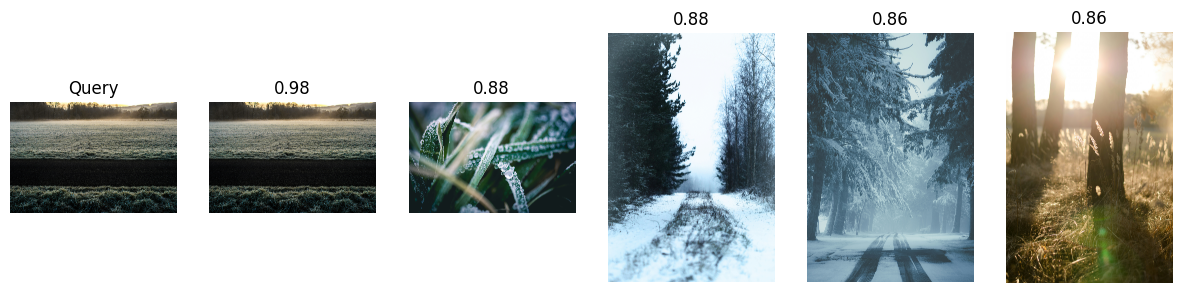

In [10]:
query_img = load_image_from_url(meta.iloc[0]["url"])
results = search(embed_image(query_img), k=5)

show_results(query_img, results)

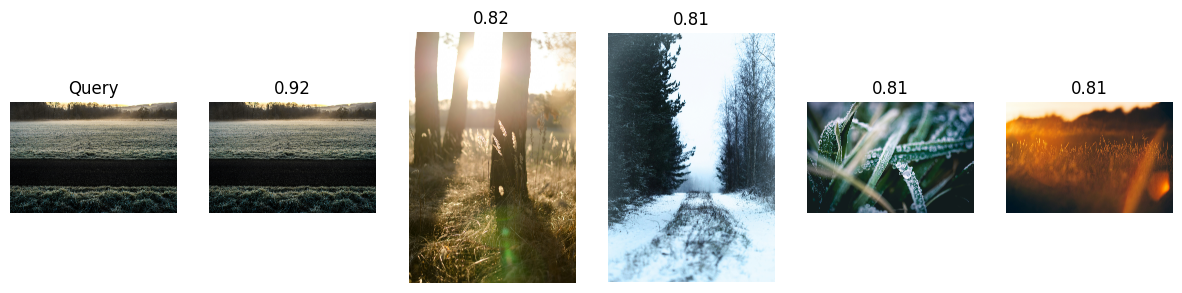

In [11]:
query_vec = embed_multimodal(
    image=query_img,
    text="sunset",
    alpha=0.7
)

results = search(query_vec)
show_results(query_img, results)